In [1]:
import jax
from jax import flatten_util, vmap, grad 
import jax.numpy as jnp
import jax.random as jr

from scipy.signal import savgol_filter
from scipy.interpolate import CubicSpline

import matplotlib.pyplot as plt
from functools import partial
import optax
from helper_fns_general import sample_gaussian_mixture, normalize_samples, CD1_gradient, setup_score_matching_loss_per_batch, run_optimization, setup_overdamped_SDE, solve_SDE, sample_forward_process, setup_MLE_loss_per_batch, setup_MLE_gradient_per_batch
from plotting_fns import plot_energy_and_distributions, plot_parameter_evolution, get_best_params
jax.config.update("jax_enable_x64", True)

CUDA backend failed to initialize: Unable to use CUDA because of the following issues with CUDA components:
Outdated cuDNN installation found.
Version JAX was built against: 8907
Minimum supported: 9100
Installed version: 8907
The local installation version must be no lower than 9100..(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


### Generate samples from a Gaussian mixture

In [2]:
# Set random seed
key = jr.PRNGKey(0)

# Parameters
N = 2  # number of dimensions
N_mixgauss = 3  # number of mixture components
n_samples = 1000

# Define mixture weights (must sum to 1)
weights = jnp.array([.5, .5])

# Define means
# Define means
means = jnp.array([
    [0.5, 0.0],   # mean of first Gaussian
    [-0.5, 0.0],  # mean of second Gaussian
])

# Define covariance matrices
covs = jnp.array([
    [[0.01, 0.0],    # covariance of first Gaussian
        [0.0, 0.01]],
    [[0.01, 0.0],   # covariance of second Gaussian
        [0.0, 0.01]],
])
# Generate samples
samples_0 = sample_gaussian_mixture(key, n_samples, weights, means, covs)
# Normalize samples
# samples = normalize_samples(samples_raw)



### Plot samples and marginal distributions

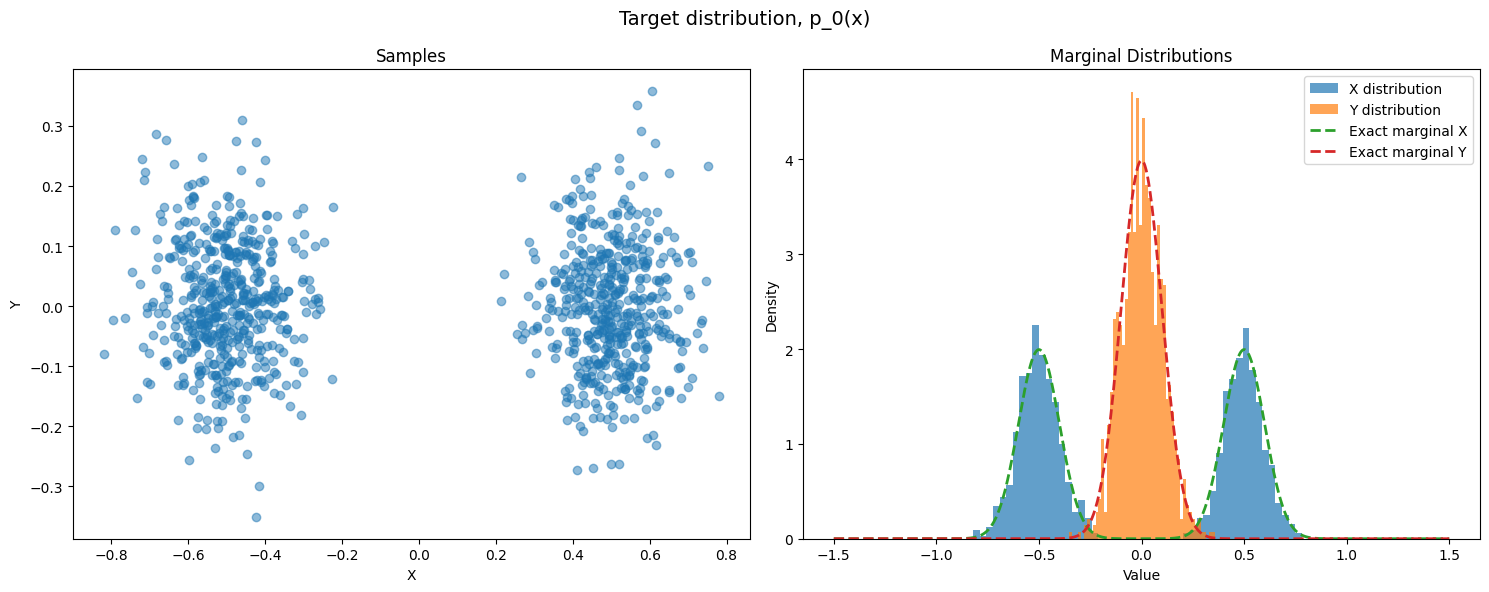

In [3]:
# ... existing code ...

# Plot samples and marginal distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Target distribution, p_0(x)', fontsize=14)

# First subplot: Scatter plot of samples
ax1.scatter(samples_0[:, 0], samples_0[:, 1], alpha=0.5)
ax1.set_title('Samples')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')

# Second subplot: Combined marginal distributions
ax2.hist(samples_0[:, 0], bins=50, density=True, alpha=0.7, label='X distribution')
ax2.hist(samples_0[:, 1], bins=50, density=True, alpha=0.7, label='Y distribution')

# Add exact marginal Gaussians
x = jnp.linspace(-1.5, 1.5, 1000)
for dim in range(2):
    marginal = jnp.zeros_like(x)
    for w, m, c in zip(weights, means, covs):
        mean = m[dim]
        std = jnp.sqrt(c[dim, dim])
        marginal += w * jnp.exp(-0.5 * ((x - mean) / std) ** 2) / (std * jnp.sqrt(2 * jnp.pi))
    ax2.plot(x, marginal, '--', linewidth=2, label=f'Exact marginal {["X", "Y"][dim]}')

ax2.set_title('Marginal Distributions')
ax2.set_xlabel('Value')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.show()

In [4]:
key, subkey = jr.split(key)
t_forward = 1.0
diffusion_rate = 1.0
samples_t = sample_forward_process(t_forward, n_samples, D=1, samples0=samples_0, key=subkey, diffusion_rate=diffusion_rate)

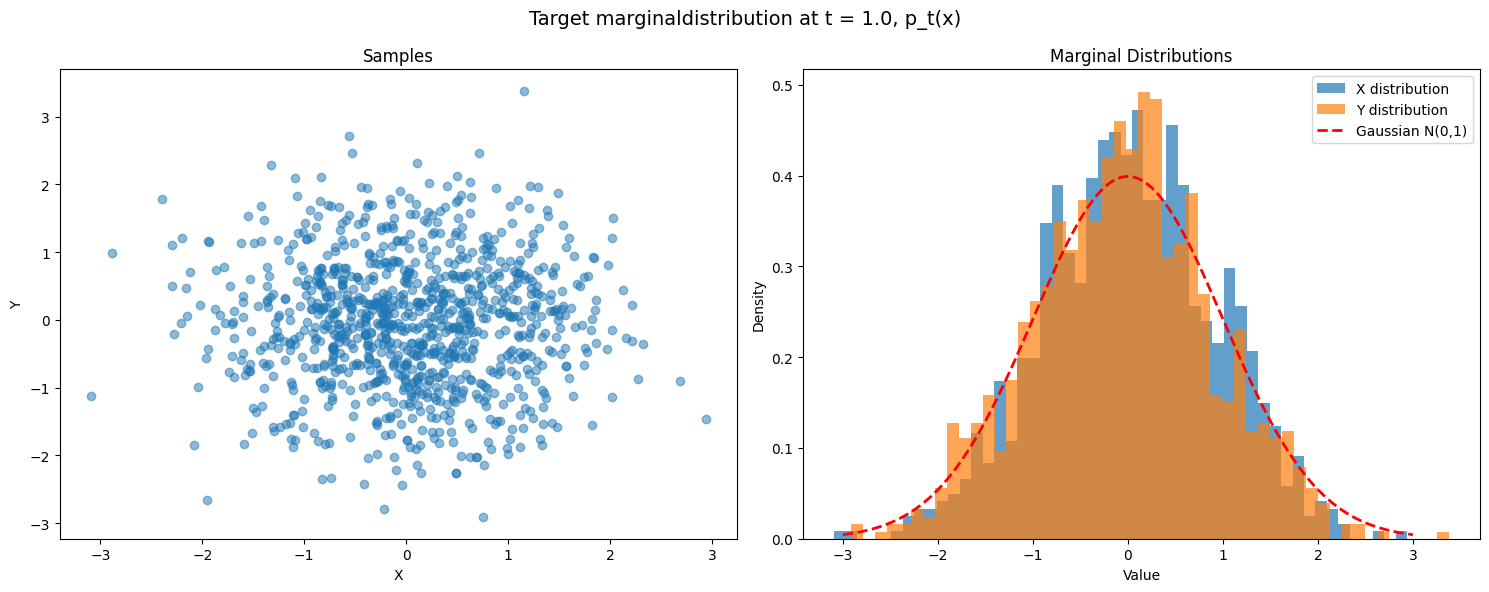

In [5]:
# Plot samples and marginal distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f'Target marginaldistribution at t = {t_forward}, p_t(x)', fontsize=14)


# First subplot: Scatter plot of samples
ax1.scatter(samples_t[:, 0], samples_t[:, 1], alpha=0.5)
ax1.set_title('Samples')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')

# Second subplot: Combined marginal distributions
ax2.hist(samples_t[:, 0], bins=50, density=True, alpha=0.7, label='X distribution')
ax2.hist(samples_t[:, 1], bins=50, density=True, alpha=0.7, label='Y distribution')

# Add Gaussian N(0,1) for comparison
x = jnp.linspace(-3, 3, 1000)  # Adjust range as needed
gaussian_pdf = (1 / jnp.sqrt(2 * jnp.pi)) * jnp.exp(-0.5 * x**2)
ax2.plot(x, gaussian_pdf, 'r--', linewidth=2, label='Gaussian N(0,1)')

ax2.set_title('Marginal Distributions')
ax2.set_xlabel('Value')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.show()

### Define energy function of duffing oscillator network

In [6]:
def energy_self_oscillator(x, k_lin, k_duff):
    return 1 / 2 * k_lin * x**2 + 1 / 4 * k_duff * x**4

def energy_self_network(x, k_lin, k_duff):
    return jnp.sum(vmap(energy_self_oscillator)(x, k_lin, k_duff))


def energy_coupling_pair(x, y, c_lin, c_optomech):
    return c_lin * x * (x - y) + c_lin * y * (y - x) + c_optomech * (x**2) * y

def energy_coupling_network(x, c_lin, c_optomech, connectivity):
    # get contribution to total energy from each pair of oscillators
    
    def _coupling_energy_pair(x, c_lin, c_optomech, pair):
        # get energy of one pair of oscillators
        i, j = pair
        return energy_coupling_pair(x[i], x[j], c_lin, c_optomech)

    # get energy of all pairs of oscillators
    return jnp.sum(
        vmap(_coupling_energy_pair, in_axes=(None, 0, 0, 0))(
            x, c_lin, c_optomech, connectivity
        )
    )

k_b = 1.0
T = .1
def _energy_duffing_network(x, k_lin, k_duff, c_lin, c_optomech, connectivity, k_b=k_b, T=T):
    # returns energy of network of oscillators given input parameters
    return (
        energy_self_network(x, k_lin, k_duff) +
        energy_coupling_network(x, c_lin, c_optomech, connectivity)
    ) / (k_b * T)

### Define initial parameters

In [7]:
N_osc = 2

k_lin_0 = jnp.array([1., 1.])
k_duff_0 = jnp.array([0., 0.])
c_lin_0 = jnp.array([0.,])
c_optomech_0 = jnp.array([0.,])
connectivity = jnp.array([[0, 1]])

args_initial = (k_lin_0, k_duff_0, c_lin_0, c_optomech_0)

flattened_args_initial, unflatten = flatten_util.ravel_pytree(args_initial)

### Bringe energy into correct form

In [8]:
def energy_duffing_network(x, flattened_args, connectivity):
    k_lin, k_duffing, c_lin, c_optomech = unflatten(flattened_args)
    return _energy_duffing_network(x, k_lin, k_duffing, c_lin, c_optomech, connectivity)
energy_fn = lambda x, flattened_args: energy_duffing_network(x, flattened_args, connectivity)
# Setup SDE functions
drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, flattened_args_initial, N_osc, time_dependent_parms=False, T=diffusion_rate)

/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.Dynami

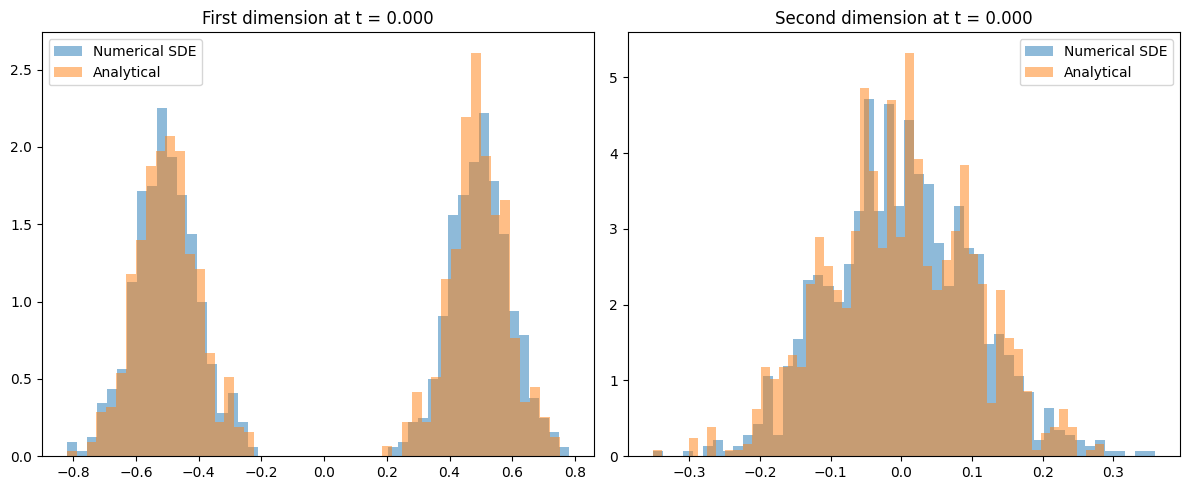

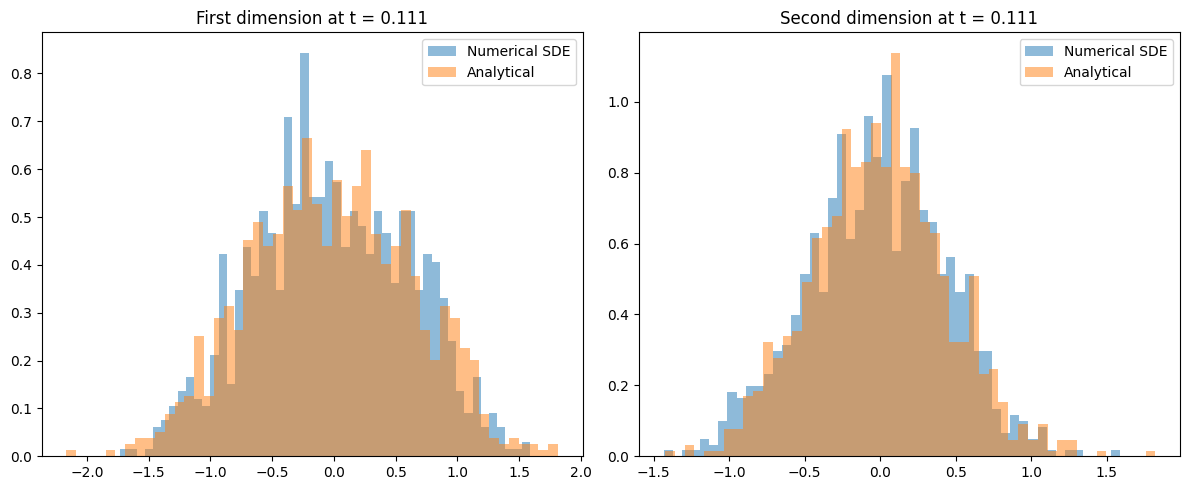

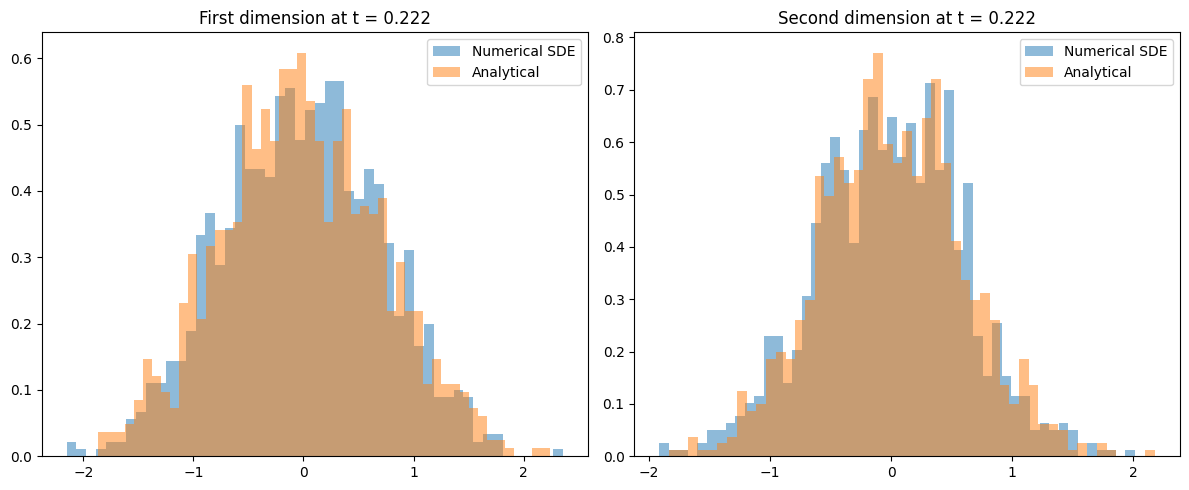

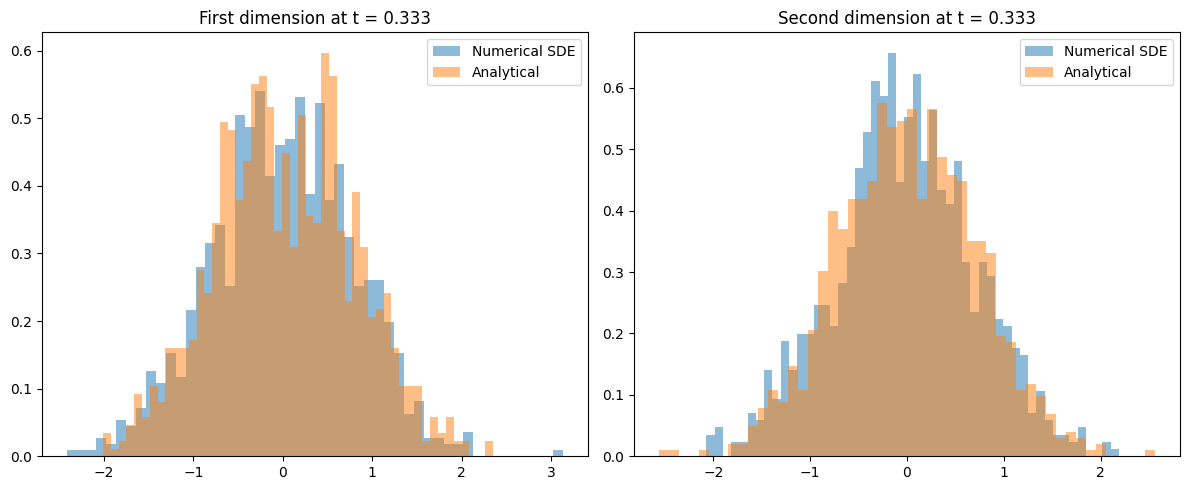

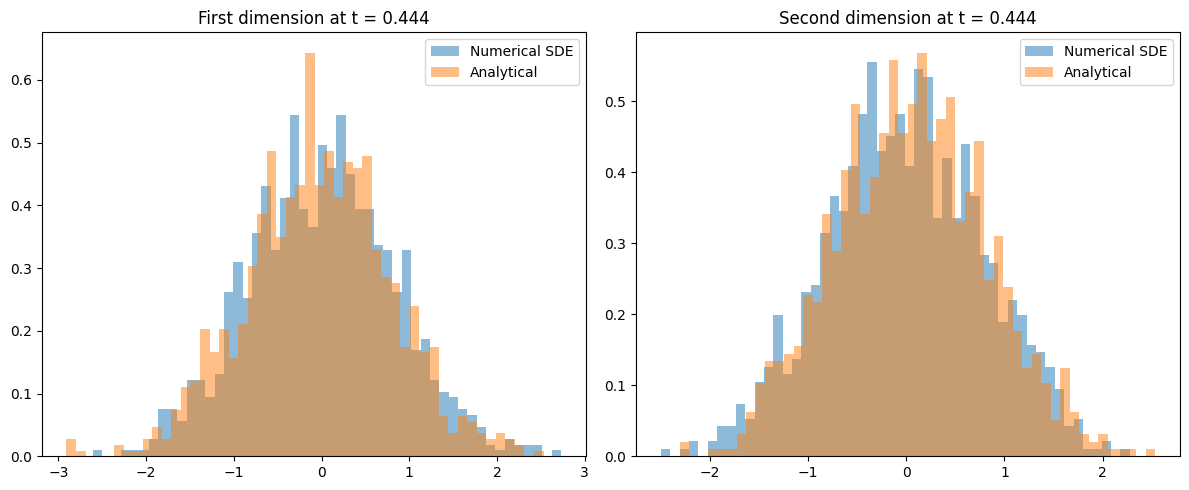

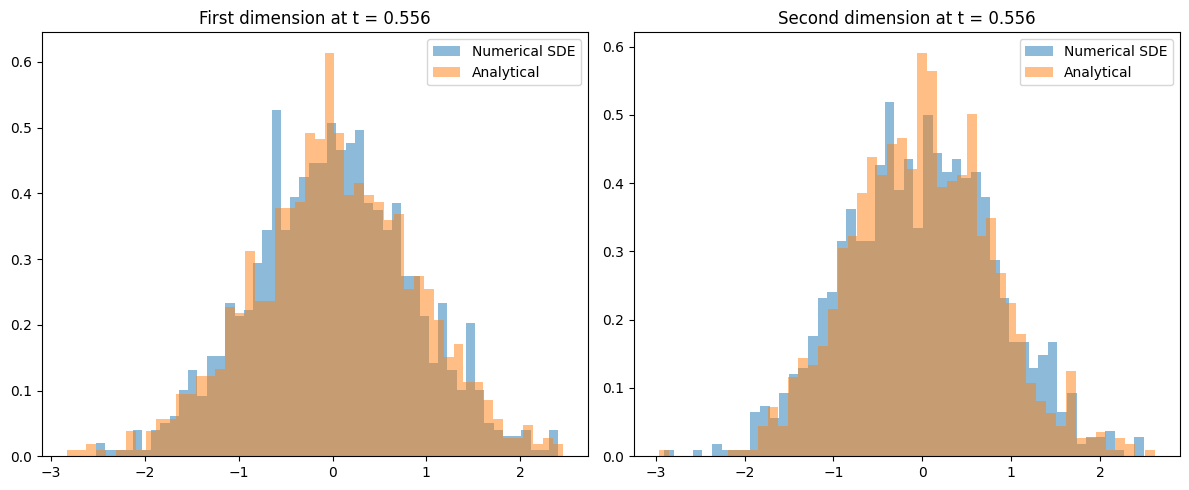

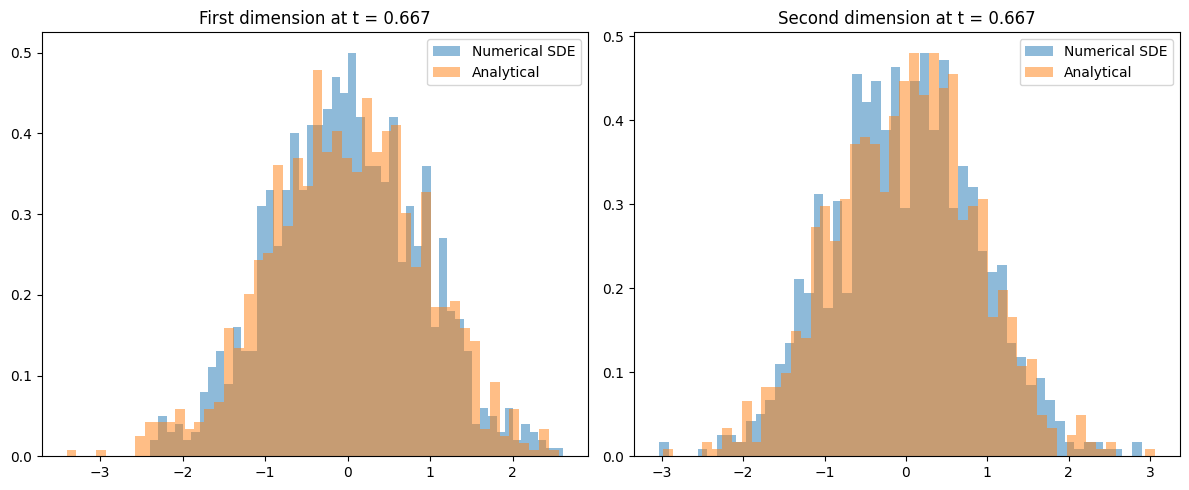

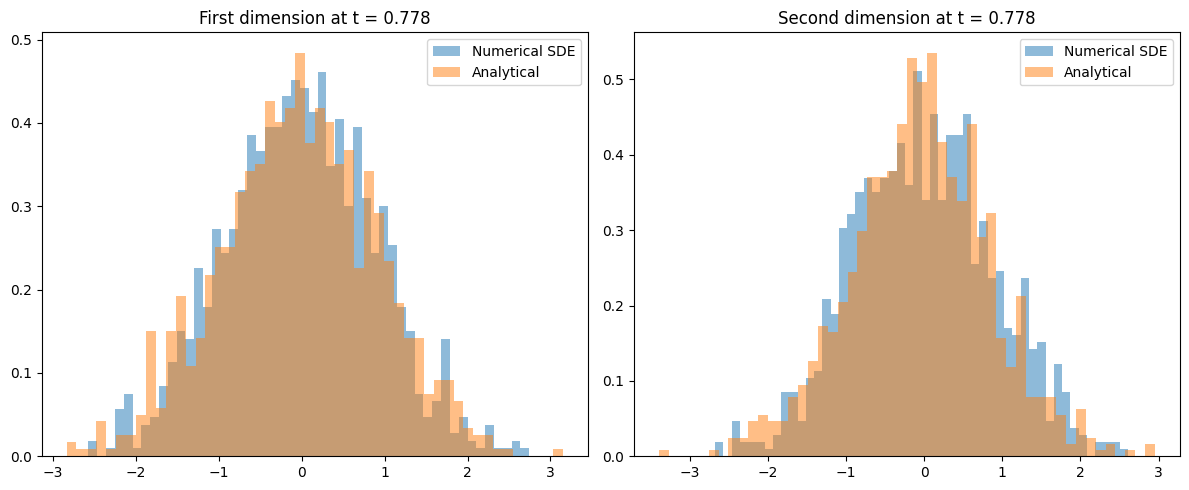

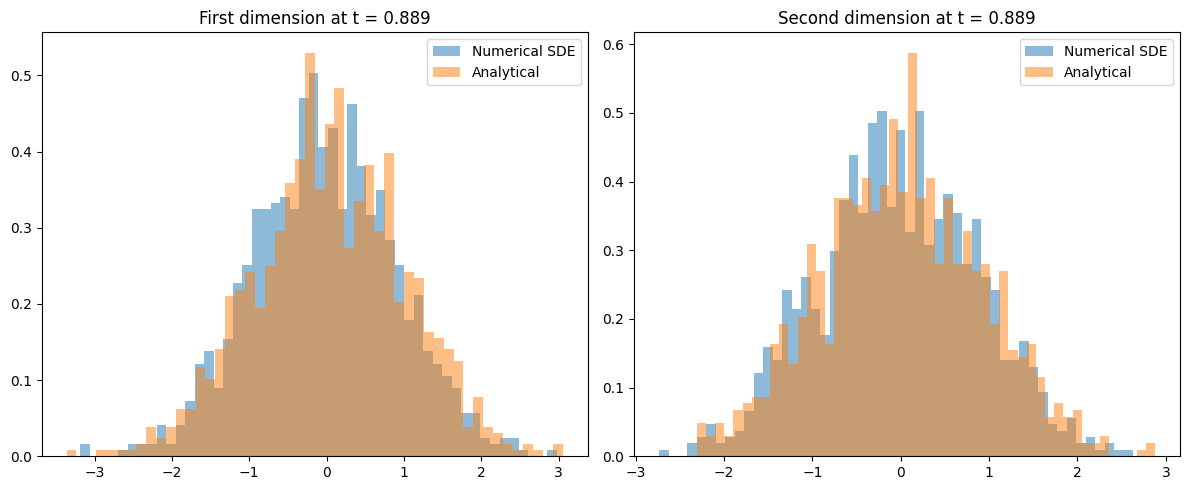

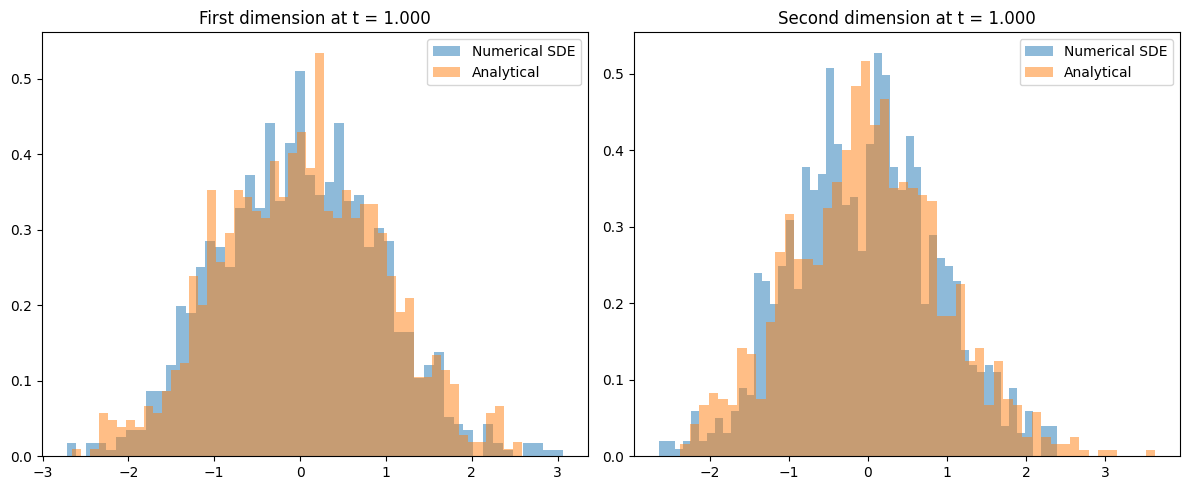

In [10]:
# Define simple drift and diffusion functions
def simple_drift_fn(t, state, args):
    return -state  # dx = -x dt

def simple_diffusion_fn(t, state, args):
    return jnp.sqrt(2.0) * jnp.eye(state.shape[0])  # sqrt(2) dW

# Create a function that solves one trajectory
def solve_one_trajectory(initial_state, key):
    solution = solve_SDE(
        simple_drift_fn, 
        simple_diffusion_fn,
        initial_state=initial_state,
        key_brownian=key,
        t0=0.0,
        t1=t_forward,
        N_samples=10,
        dt0=0.0001
    )
    return solution.ys

# Generate unique keys for each trajectory
key, subkey = jr.split(key)
keys = jr.split(subkey, samples_0.shape[0])

# Vmap over both initial conditions and keys
vmapped_solve = jax.vmap(solve_one_trajectory, in_axes=(0, 0))
all_trajectories = vmapped_solve(samples_0, keys)  # shape: (n_samples, n_timesteps, n_dims)

# Compare with analytical solution at each time point
time_points = jnp.linspace(0, t_forward, 10)
for i, t in enumerate(time_points):
    # Get numerical solution at this time
    numerical_samples = all_trajectories[:, i, :]
    
    # Get analytical solution
    key, subkey = jr.split(key)
    analytical_samples = sample_forward_process(t, n_samples, D=1, samples0=samples_0, key=subkey, diffusion_rate=1.0)
    
    # Plot comparison
    plt.figure(figsize=(12, 5))
    
    # First dimension
    plt.subplot(1, 2, 1)
    plt.hist(numerical_samples[:, 0], bins=50, alpha=0.5, label='Numerical SDE', density=True)
    plt.hist(analytical_samples[:, 0], bins=50, alpha=0.5, label='Analytical', density=True)
    plt.title(f'First dimension at t = {t:.3f}')
    plt.legend()
    
    # Second dimension
    plt.subplot(1, 2, 2)
    plt.hist(numerical_samples[:, 1], bins=50, alpha=0.5, label='Numerical SDE', density=True)
    plt.hist(analytical_samples[:, 1], bins=50, alpha=0.5, label='Analytical', density=True)
    plt.title(f'Second dimension at t = {t:.3f}')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

In [ ]:
def solve_one_trajectory(initial_state, key):
    # Setup time points
    ts = jnp.linspace(0, t_forward, 10)
    
    # Simple drift and diffusion terms
    def simple_drift_fn(t, state, args):
        return -state
    
    def simple_diffusion_fn(t, state, args):
        return jnp.sqrt(2.0) * jnp.eye(state.shape[0])
    
    # Create Brownian motion with unique key
    bm = diffrax.VirtualBrownianTree(
        t0=0.0,
        t1=t_forward,
        tol=1e-3,
        shape=initial_state.shape,
        key=key
    )
    
    # Setup terms
    terms = diffrax.MultiTerm(
        diffrax.ODETerm(simple_drift_fn),
        diffrax.ControlTerm(simple_diffusion_fn, bm)
    )
    
    # Solve
    solution = diffrax.diffeqsolve(
        terms,
        diffrax.Euler(),
        t0=0.0,
        t1=t_forward,
        dt0=0.0001,
        y0=initial_state,
        saveat=diffrax.SaveAt(ts=ts),
        max_steps=None
    )
    
    return solution.ys

# Generate unique keys for each trajectory
key, subkey = jr.split(key)
keys = jr.split(subkey, samples_0.shape[0])

# Vmap over all initial conditions and keys
vmapped_solve = jax.vmap(solve_one_trajectory)
all_trajectories = vmapped_solve(samples_0, keys)

# Compare with analytical solution at each time point
time_points = jnp.linspace(0, t_forward, 10)
for i, t in enumerate(time_points):
    # Get numerical solution at this time
    numerical_samples = all_trajectories[:, i, :]
    
    # Get analytical solution
    key, subkey = jr.split(key)
    analytical_samples = sample_forward_process(t, n_samples, D=1, samples0=samples_0, key=subkey, diffusion_rate=1.0)
    
    # Plot comparison
    plt.figure(figsize=(12, 5))
    
    # First dimension
    plt.subplot(1, 2, 1)
    plt.hist(numerical_samples[:, 0], bins=50, alpha=0.5, label='Numerical SDE', density=True)
    plt.hist(analytical_samples[:, 0], bins=50, alpha=0.5, label='Analytical', density=True)
    plt.title(f'First dimension at t = {t:.3f}')
    plt.legend()
    
    # Second dimension
    plt.subplot(1, 2, 2)
    plt.hist(numerical_samples[:, 1], bins=50, alpha=0.5, label='Numerical SDE', density=True)
    plt.hist(analytical_samples[:, 1], bins=50, alpha=0.5, label='Analytical', density=True)
    plt.title(f'Second dimension at t = {t:.3f}')
    plt.legend()
    
    plt.tight_layout()
    plt.show()